In [11]:
import chainladder as cl
import pandas as pd
print(clrd_wc.index)

                                GRNAME     LOB
0   American Assoc Of Othodontists RRG  medmal
1     California Healthcare Ins Co Inc  medmal
2          Campmed Cas & Ind Co Inc MD  medmal
3                Clinic Mut Ins Co RRG  medmal
4        Community Blood Cntr Exch RRG  medmal
5     Controlled Risk Ins Co Of VT Inc  medmal
6                      Dentists Ins Co  medmal
7          Eastern Dentists Ins Co RRG  medmal
8              Franklin Cas Ins Co RRG  medmal
9                       Great Amer Grp  medmal
10                 Health Care Ind Inc  medmal
11                    Homestead Ins Co  medmal
12            Louisiana Med Mut Ins Co  medmal
13                     MCIC VT Inc RRG  medmal
14                          MHA Ins Co  medmal
15                     Markel Corp Grp  medmal
16            Medical Mut Ins Co Of ME  medmal
17      Michigan Professional Ins Exch  medmal
18                        NCMIC Ins Co  medmal
19            National American Ins Co  medmal
20           

In [12]:
clrd = cl.load_sample('clrd')['CumPaidLoss']
clrd_wc = clrd[clrd['LOB'] == 'medmal'] #niestabilne szkody medyczne

industry_wc = clrd_wc.sum()

allstate_wc_industry_pattern = cl.Chainladder().fit(industry_wc).predict(
    clrd_wc.loc['Utah Medical Ins Assoc']
).ultimate_  #branża 
 
allstate_wc_company_pattern = cl.Chainladder().fit(
    clrd_wc.loc['Utah Medical Ins Assoc']
).ultimate_ #firma 

df = pd.DataFrame(
    {
        "allstate_wc_industry_pattern": allstate_wc_industry_pattern.to_frame(
        ).iloc[:, 0],
        "allstate_wc_company_pattern": allstate_wc_company_pattern.to_frame(
        ).iloc[:, 0],
    }
).fillna(0)
df.index = pd.to_datetime(df.index).year
df.index.name = "Origin Year"
df.reset_index()

,Origin Year,allstate_wc_industry_pattern,allstate_wc_company_pattern
0,1988,6241.000000,6241.000000
1,1989,6018.070285,5911.000000
2,1990,9524.462839,9088.772836
3,1991,9394.767075,8842.043906
4,1992,14432.807084,13451.270269
5,1993,14093.103994,12777.753461
6,1994,18546.552097,16061.866724
7,1995,17660.068109,15915.847728
8,1996,13156.943066,12070.290368
9,1997,25666.900629,16516.683047


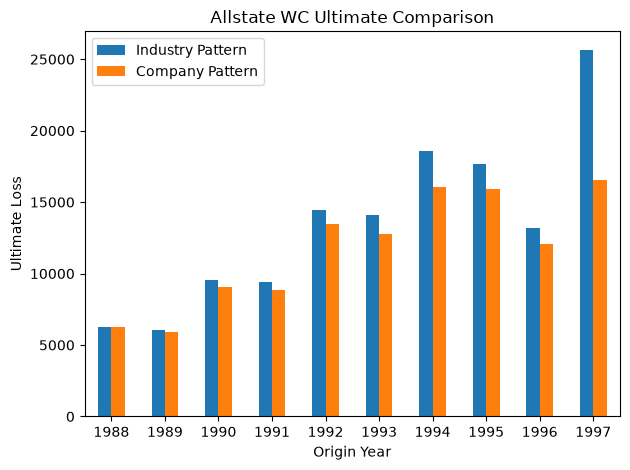

In [13]:
import matplotlib.pyplot as plt

plot_df = df[[
    "allstate_wc_industry_pattern",
    "allstate_wc_company_pattern"
]].rename(columns={
    "allstate_wc_industry_pattern": "Industry Pattern",
    "allstate_wc_company_pattern": "Company Pattern"
})

# Create bar chart
plot_df.plot(kind='bar')

# Labels and title
plt.title("Allstate WC Ultimate Comparison")
plt.ylabel("Ultimate Loss")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


#Gdy słucham całej branży, odkładam większą rezerwę. Gdy słucham tylko tej firmy, odkładam mniejszą rezerwę